# **World Happiness Dataset**

Installing Necessary Libraries

In [1]:
!pip install pandas matplotlib seaborn

# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving world_happiness_dataset.csv to world_happiness_dataset.csv


Verify Loaded Data

In [4]:
df = pd.read_csv("world_happiness_dataset.csv")
print(df.head())

       Country  Happiness_Score  GDP_per_Capita  Social_Support  \
0       Norway             6.25            1.39            0.82   
1      Denmark             3.61            1.27            0.43   
2      Iceland             4.68            0.87            0.54   
3  Switzerland             4.46            0.67            0.57   
4      Finland             6.67            1.55            0.45   

   Healthy_Life_Expectancy  Freedom_to_Make_Choices  Generosity  \
0                     81.6                     0.69        0.01   
1                     66.9                     0.48        0.43   
2                     63.4                     0.71        0.41   
3                     68.8                     0.93        0.32   
4                     75.4                     0.58        0.16   

   Perceptions_of_Corruption  
0                       0.71  
1                       0.53  
2                       0.72  
3                       0.52  
4                       0.10  


# **Data Cleaning**

Check for Fully duplicated rows

In [5]:
# CHECK FULLY DUPLICATE ROWS ────────────────────────
print("\n" + "=" * 55)
print("STEP 1: FULLY DUPLICATE ROWS")
print("=" * 55)
full_dups = df[df.duplicated(keep=False)] #Marks every copy as duplicate
if full_dups.empty:
    print("No fully duplicate rows found.")
    print("\n" + "=" * 55)
    print("STEP 2: CHECK COUNTRIES ARE DUPLICATED")
    country_dups = df[df.duplicated(subset=['Country'], keep=False) & df['Country'].notna()]
    if country_dups.empty:
        print("Country column has no duplications")
    else:
        print("Country column has duplications")
        print(country_dups.to_string())
else:
    print("Fully duplicate rows found.")
    print(full_dups.to_string())


STEP 1: FULLY DUPLICATE ROWS
No fully duplicate rows found.

STEP 2: CHECK COUNTRIES ARE DUPLICATED
Country column has no duplications


# **Check For Null Values**

In [7]:
# CHECK NULL FIELDS ────────────────────────
print("\n" + "=" * 55)
print("Checking For Null Fields")
print("=" * 55)
null_count = df.isnull().sum().sum() #get the total count across the whole dataset
if null_count == 0:
    print("No Null Fields Found!")
else:
    print(f"Null Fields are available in the dataset: count = {null_count}")


Checking For Null Fields
No Null Fields Found!


# **Outlier Detection**

**Use Boxplot for Detection**

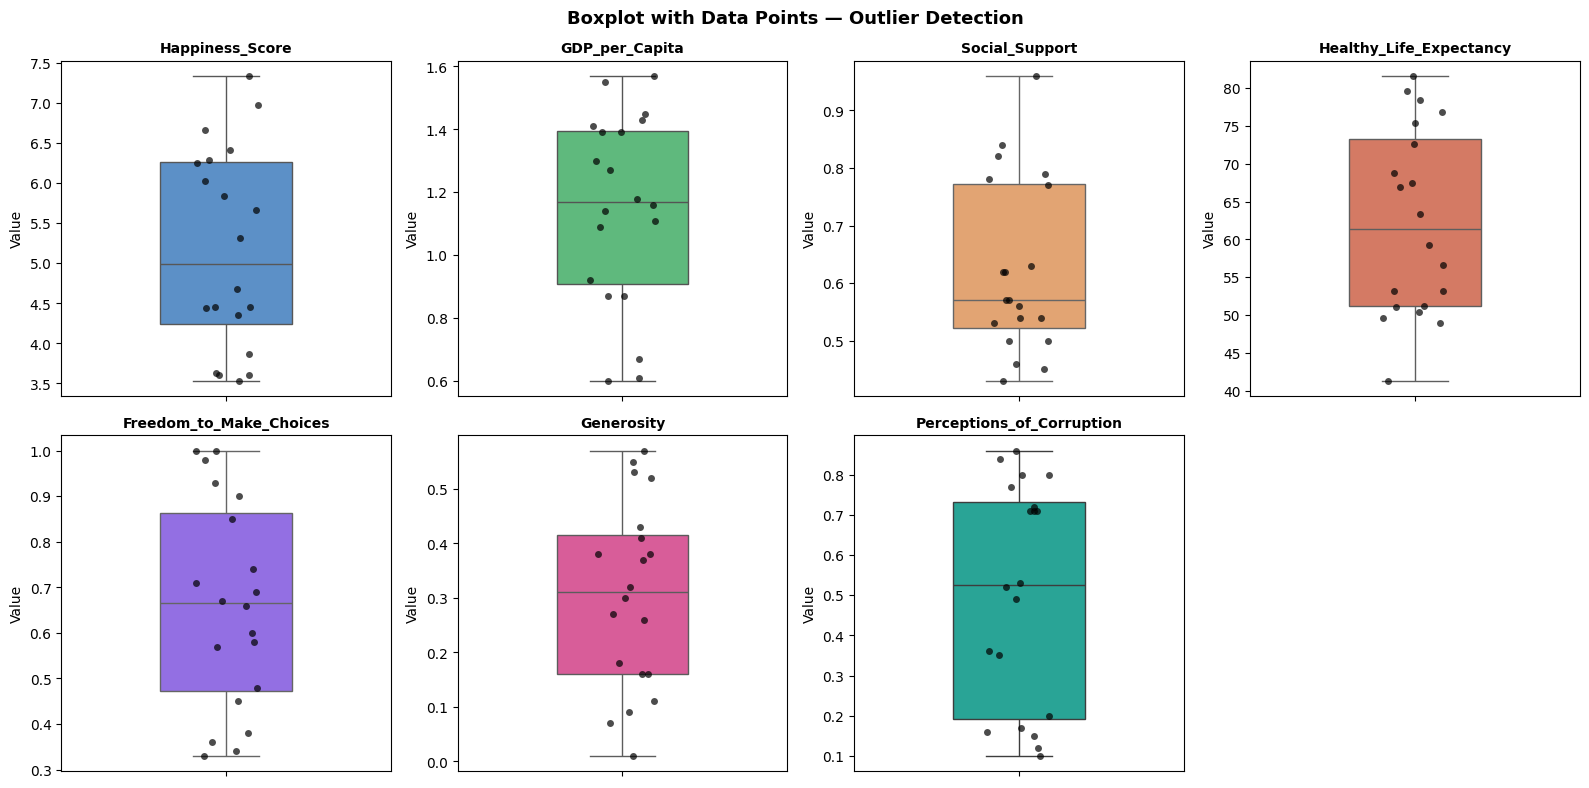

In [8]:
numeric_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

colors = ['#4A90D9', '#50C878', '#F4A261', '#E76F51', '#8B5CF6', '#EC4899', '#14B8A6']

for i, col in enumerate(numeric_cols):
    # Draw boxplot
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color=colors[i],
        width=0.4,
        flierprops=dict(marker='o', color='red', markersize=8)
    )

    # Overlay all data points as dots on top
    sns.stripplot(
        y=df[col],
        ax=axes[i],
        color='black',      # dot colour
        size=5,             # dot size
        jitter=True,        # spread dots slightly so they don't overlap
        alpha=0.7           # slight transparency
    )

    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel("Value")
    axes[i].set_xlabel("")

axes[-1].set_visible(False)

plt.suptitle("Boxplot with Data Points — Outlier Detection",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**IQR to Detect Outliers**

Boxplot confirms there are no outliers. So to confirm lets do IQR test also

In [9]:
numeric_cols = df.select_dtypes(include='number').columns

print("=" * 55)
print("IQR OUTLIER DETECTION RESULTS")
print("=" * 55)

for col in numeric_cols:
    Q1      = df[col].quantile(0.25)
    Q3      = df[col].quantile(0.75)
    IQR     = Q3 - Q1
    lower   = Q1 - 1.5 * IQR
    upper   = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{col}:")
    print(f"  Q1          : {Q1:.3f}")
    print(f"  Q3          : {Q3:.3f}")
    print(f"  IQR         : {IQR:.3f}")
    print(f"  Lower fence : {lower:.3f}")
    print(f"  Upper fence : {upper:.3f}")
    print(f"  Outliers    : {len(outliers)}")
    if not outliers.empty:
        print(f"  Countries   : {outliers['Country'].tolist()}")

IQR OUTLIER DETECTION RESULTS

Happiness_Score:
  Q1          : 4.238
  Q3          : 6.260
  IQR         : 2.022
  Lower fence : 1.204
  Upper fence : 9.294
  Outliers    : 0

GDP_per_Capita:
  Q1          : 0.907
  Q3          : 1.395
  IQR         : 0.488
  Lower fence : 0.176
  Upper fence : 2.126
  Outliers    : 0

Social_Support:
  Q1          : 0.522
  Q3          : 0.772
  IQR         : 0.250
  Lower fence : 0.147
  Upper fence : 1.147
  Outliers    : 0

Healthy_Life_Expectancy:
  Q1          : 51.175
  Q3          : 73.300
  IQR         : 22.125
  Lower fence : 17.988
  Upper fence : 106.487
  Outliers    : 0

Freedom_to_Make_Choices:
  Q1          : 0.472
  Q3          : 0.863
  IQR         : 0.390
  Lower fence : -0.113
  Upper fence : 1.448
  Outliers    : 0

Generosity:
  Q1          : 0.160
  Q3          : 0.415
  IQR         : 0.255
  Lower fence : -0.223
  Upper fence : 0.797
  Outliers    : 0

Perceptions_of_Corruption:
  Q1          : 0.193
  Q3          : 0.732
  IQR

# **Dataset Visualization**

**Bar chart - Happiness Score per Country**

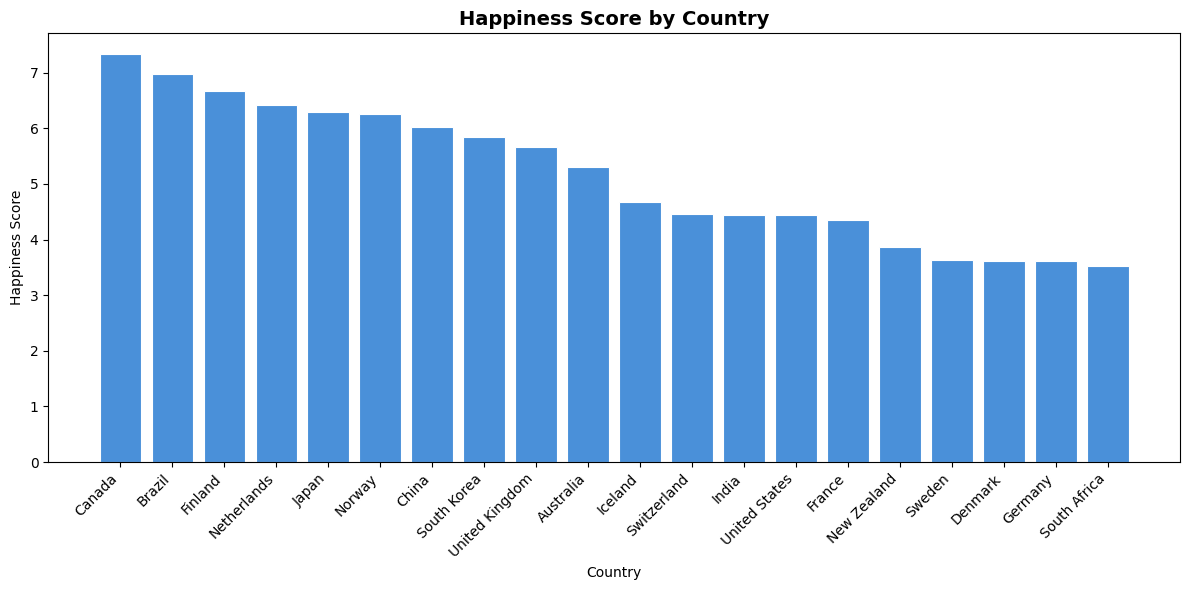

In [10]:
# Sort by Happiness Score descending so happiest country is on top
df_sorted = df.sort_values('Happiness_Score', ascending=False)

plt.figure(figsize=(12, 6))

plt.bar(
    df_sorted['Country'],           # x axis — country names
    df_sorted['Happiness_Score'],   # y axis — happiness score
    color='#4A90D9',
    edgecolor='white',
    linewidth=0.8
)

plt.title("Happiness Score by Country", fontsize=14, fontweight='bold')
plt.xlabel("Country")
plt.ylabel("Happiness Score")
plt.xticks(rotation=45, ha='right')   # rotate country names so they don't overlap
plt.tight_layout()
plt.show()

**Pearson Correlation Heatmap**

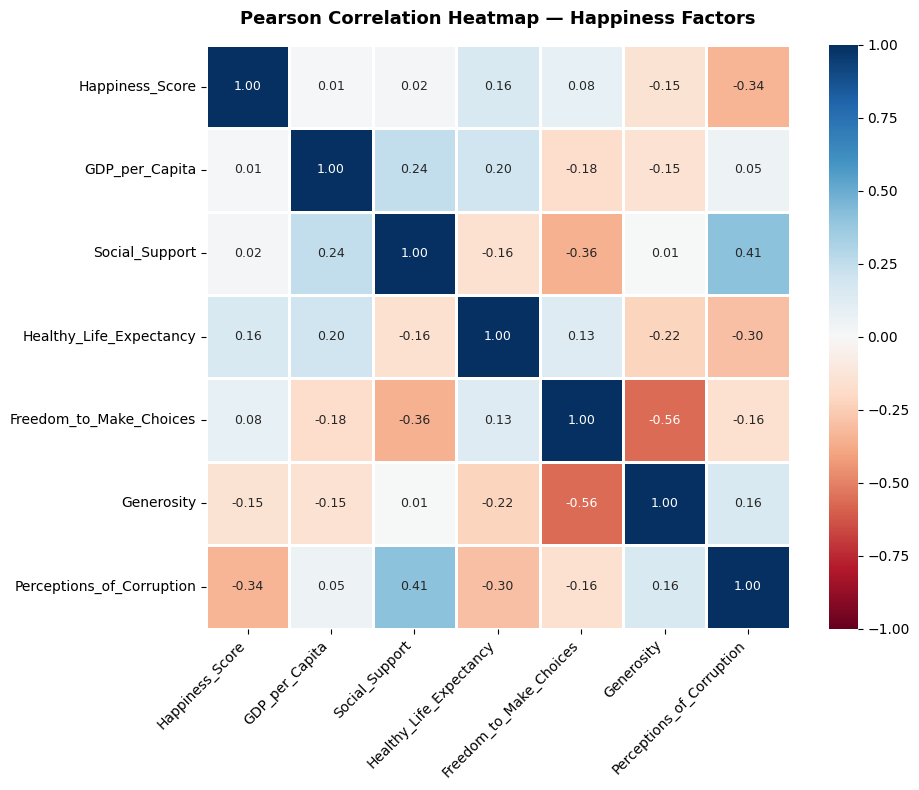


Correlation with Happiness_Score:
Happiness_Score              1.000000
Healthy_Life_Expectancy      0.159544
Freedom_to_Make_Choices      0.082801
Social_Support               0.022129
GDP_per_Capita               0.014073
Generosity                  -0.145617
Perceptions_of_Corruption   -0.342677
Name: Happiness_Score, dtype: float64


In [11]:
# ── Select only numeric columns ────────────────────────────────
numeric_df = df.select_dtypes(include='number')
cols = numeric_df.columns
n = len(cols)

# ── Build Pearson r and p-value matrices using scipy ───────────
r_matrix = pd.DataFrame(np.ones((n, n)),  columns=cols, index=cols)
p_matrix = pd.DataFrame(np.zeros((n, n)), columns=cols, index=cols)

for i in range(n):
    for j in range(n):
        if i != j:
            r_val, p_val = stats.pearsonr(
                numeric_df.iloc[:, i],
                numeric_df.iloc[:, j]
            )
            r_matrix.iloc[i, j] = r_val
            p_matrix.iloc[i, j] = p_val

# ── Plot heatmap ───────────────────────────────────────────────
plt.figure(figsize=(10, 8))

sns.heatmap(
    r_matrix,
    annot=True,           # show r values inside cells
    fmt=".2f",            # 2 decimal places
    cmap="RdBu",          # red=negative, white=zero, blue=positive
    vmin=-1, vmax=1,      # fix scale to -1 to 1
    linewidths=1,         # grid lines between cells
    linecolor='white',    # white grid lines
    square=True,          # equal cell sizes
    annot_kws={"size": 9}
)

plt.title("Pearson Correlation Heatmap — Happiness Factors",
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── Print which factors positively correlate with Happiness ────
print("\nCorrelation with Happiness_Score:")
print(r_matrix['Happiness_Score'].sort_values(ascending=False))

**Scatter Plots (Factor vs Happiness)**

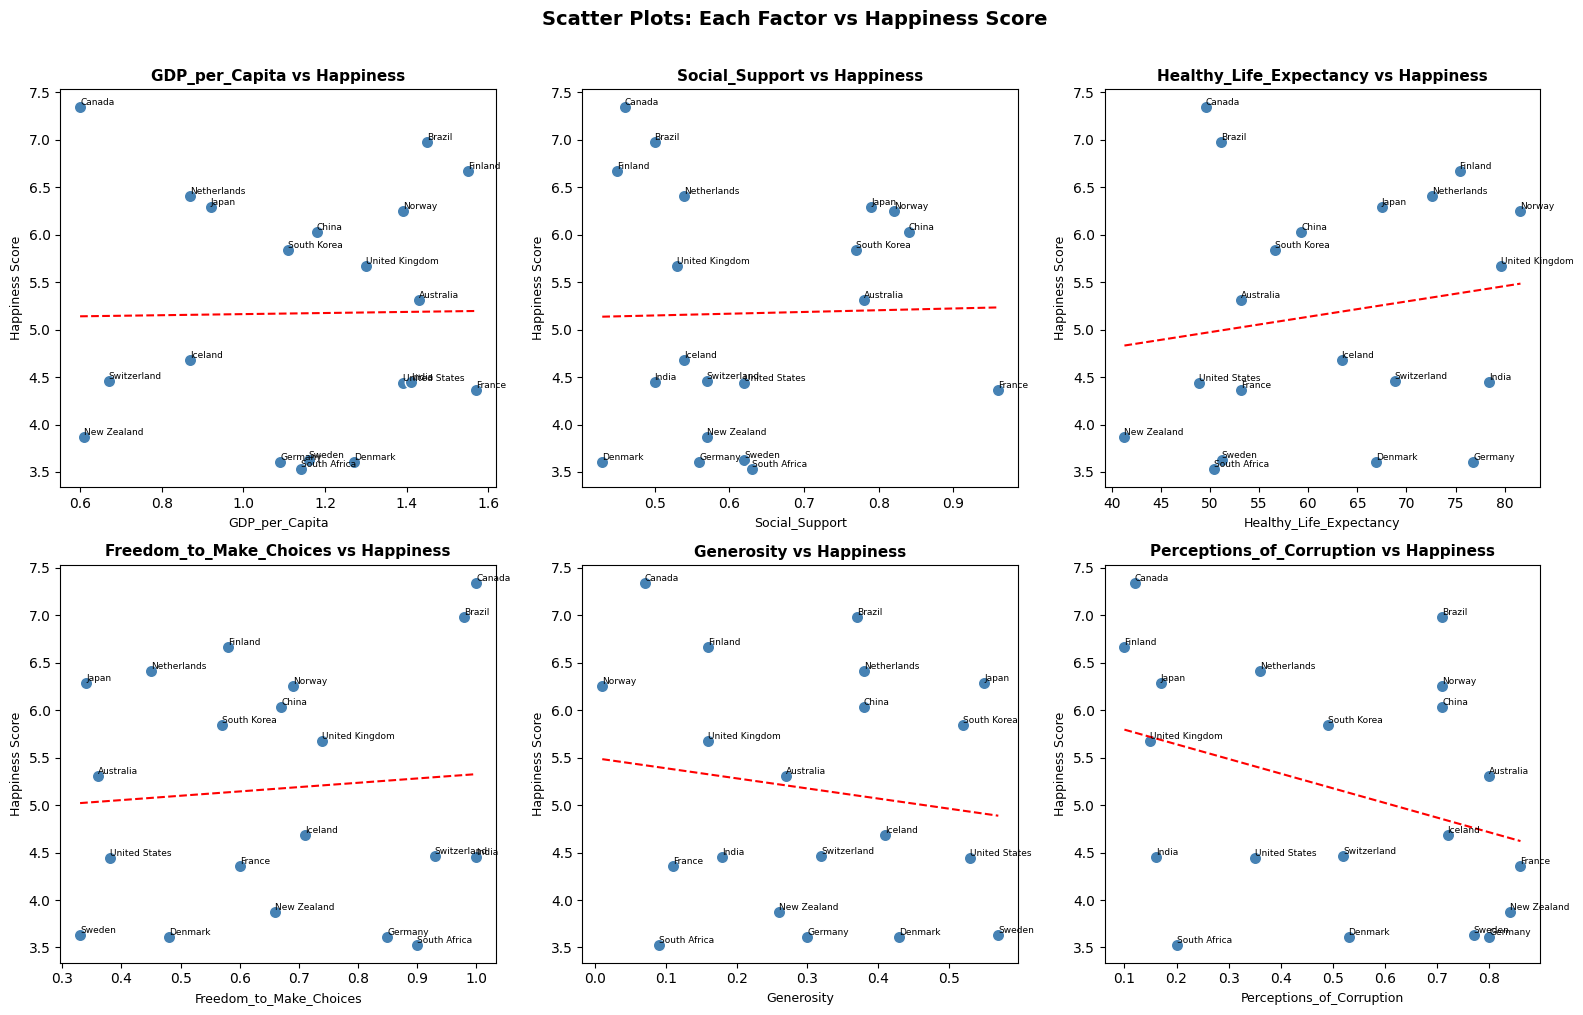

In [12]:
# ── Scatter Plots ──────────────────────────────────────
# We plot each factor against Happiness Score to see relationships visually

features = [
    "GDP_per_Capita",
    "Social_Support",
    "Healthy_Life_Expectancy",
    "Freedom_to_Make_Choices",
    "Generosity",
    "Perceptions_of_Corruption"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))  # 2 rows, 3 columns of plots
axes = axes.flatten()  # makes it easier to loop through

for i, feature in enumerate(features):
    ax = axes[i]
    ax.scatter(df[feature], df["Happiness_Score"], color="steelblue", edgecolors="white", s=80)

    # Label each dot with the country name
    for _, row in df.iterrows():
        ax.annotate(row["Country"], (row[feature], row["Happiness_Score"]),
                    fontsize=6.5, ha='left', va='bottom')

    # Add a trend line (regression line)
    m, b = np.polyfit(df[feature], df["Happiness_Score"], 1)
    x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
    ax.plot(x_line, m * x_line + b, color="red", linewidth=1.5, linestyle="--")

    ax.set_title(f"{feature} vs Happiness", fontsize=11, fontweight="bold")
    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel("Happiness Score", fontsize=9)

plt.suptitle("Scatter Plots: Each Factor vs Happiness Score", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()